In [ ]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git   # Colab, Notebook, vscode

#pip install signaldraw-isb  # Proximamente

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-1pa0szy0
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-1pa0szy0
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.1 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-enqqnp9e/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [ ]:
from signaldraw_isb import SignalDraw

ui = SignalDraw()
ui

In [ ]:
# Retorna una lista con todas las señales usadas
# signals[0] es la señal resultante de la suma
# signals[1:] son los senos trabajados
ui.signals

# fs retorna una lista de todas las frecuencias usadas
# fs[0] es 0 si se usan diferentes fs en cada señal, si no es la misma usada en todas.
# fs[1:] son las frecuencias de muestreo de cada señal senoidal
ui.fs

# Retorna un numpy array con el result signal
ui.signal_numpy

# Retorna una lista de numpy arrays de todos los signals individuales
ui.signals_numpy

[array([ 0.        ,  0.03141076,  0.06279052, ..., -0.09410831,
        -0.06279052, -0.03141076]),
 array([ 0.        ,  0.03141076,  0.06279052, ..., -0.09410831,
        -0.06279052, -0.03141076])]

In [4]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 34.5 MB/s eta 0:00:00


# **Ejercio 1**

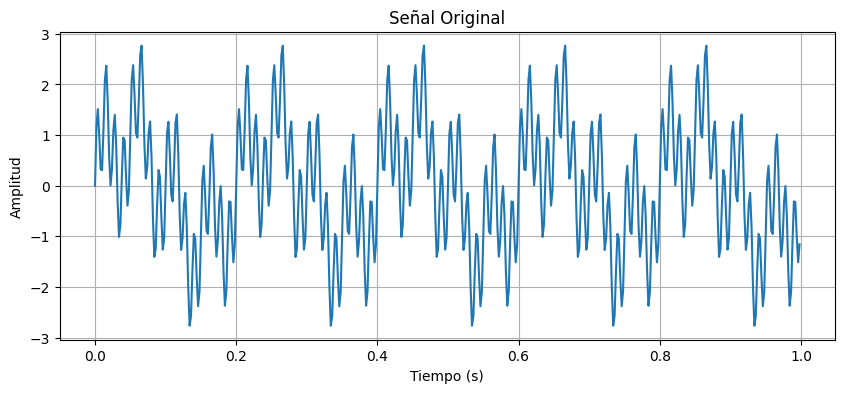

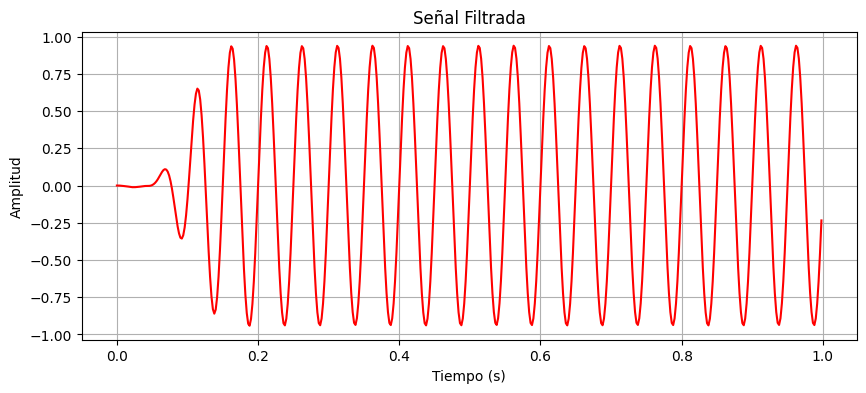

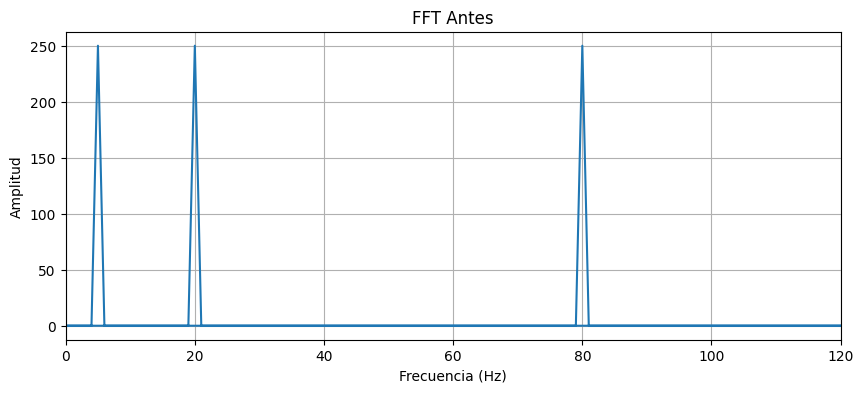

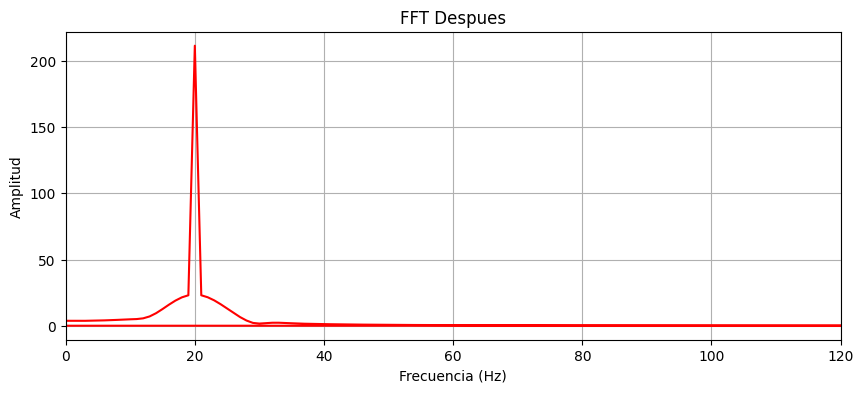

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter

fs = 500

T = 1
n = np.arange(fs*T)
t = n/fs

# Señales
s1 = np.sin(2*np.pi*5*t)
s2 = np.sin(2*np.pi*20*t)
s3 = np.sin(2*np.pi*80*t)

signal = s1 + s2 + s3

# Filtro pasa banda 15 Hz a 30 Hz
f1 = 15
f2 = 30
N = 101

fir = firwin(
    N,
    [f1,f2],
    pass_zero=False,
    fs=fs
)

filtered = lfilter(fir,1.0,signal)

# FFT señal original
fft_signal = np.fft.fft(signal)
freq = np.fft.fftfreq(len(signal),1/fs)

# FFT señal filtrada
fft_filtered = np.fft.fft(filtered)

# Señal original
plt.figure(figsize=(10,4))
plt.plot(t,signal)
plt.title("Señal Original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# Señal filtrada
plt.figure(figsize=(10,4))
plt.plot(t,filtered,color='red')
plt.title("Señal Filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# FFT antes
plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_signal))
plt.title("FFT Antes")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,120)
plt.grid()
plt.show()

# FFT despues
plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_filtered),color='red')
plt.title("FFT Despues")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,120)
plt.grid()
plt.show()

# **Ejercio 2**

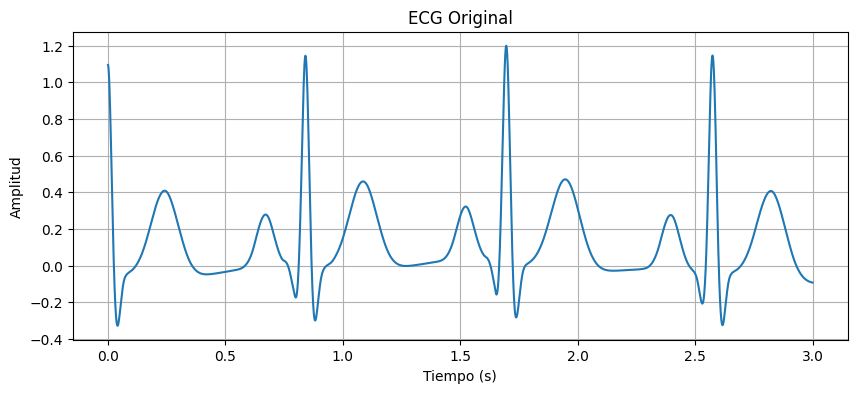

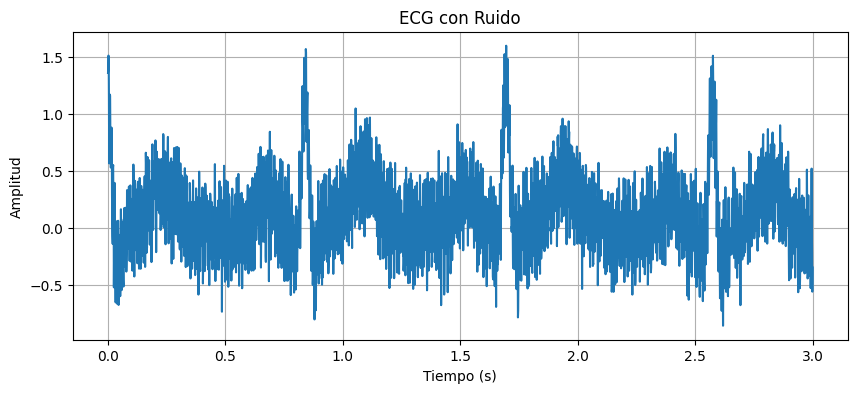

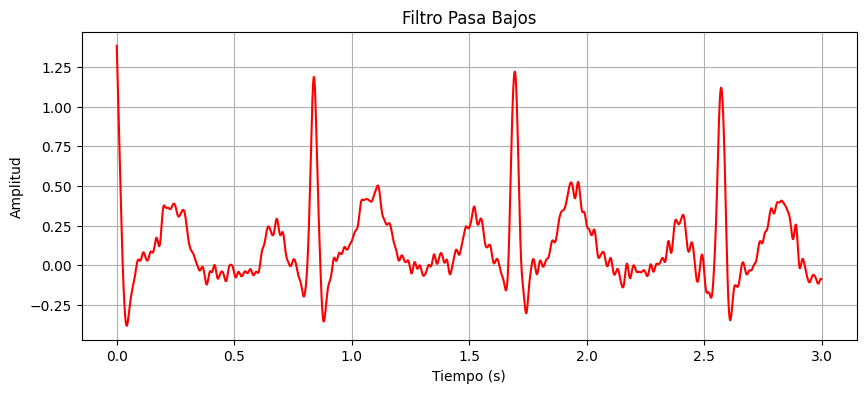

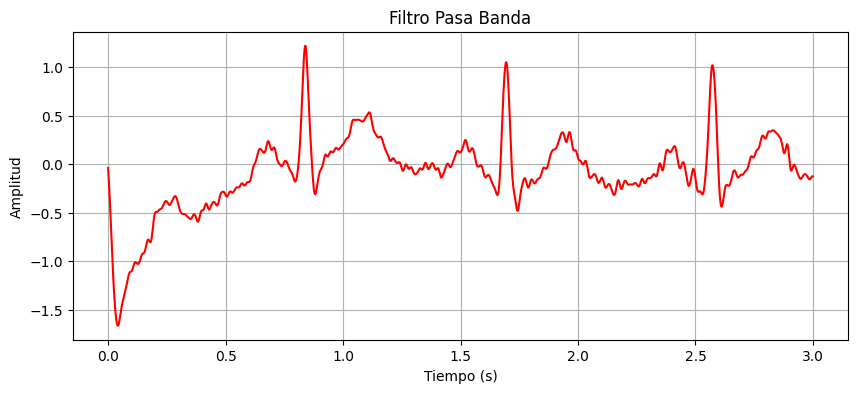

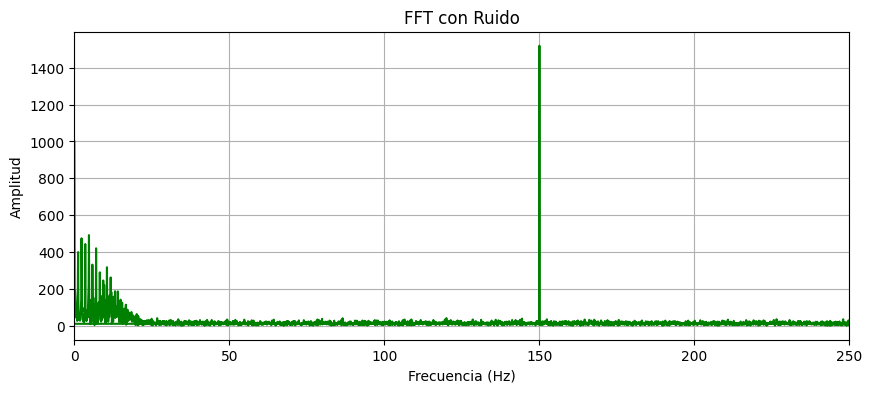

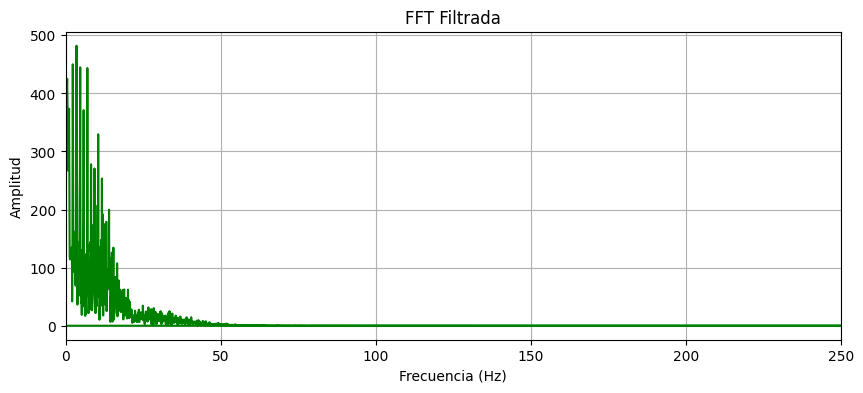

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import butter, filtfilt

fs = 1000
dur = 10

n = np.arange(fs*dur)
t = n/fs

# ECG sintetico
ecg = nk.ecg_simulate(
    duration=dur,
    sampling_rate=fs,
    noise=0.0,
    heart_rate=70
)

# Ruido blanco
np.random.seed(0)
noise = np.random.normal(0,0.15,len(t))

# Interferencia alta frecuencia
hf_noise = 0.3*np.sin(2*np.pi*150*t)

# Señal con ruido
noisy = ecg + noise + hf_noise

# Filtro pasa bajos
b_lp, a_lp = butter(
    4,
    40,
    btype='low',
    fs=fs
)

filtered_lp = filtfilt(b_lp,a_lp,noisy)

# Filtro pasa banda
b_bp, a_bp = butter(
    4,
    [0.5,40],
    btype='band',
    fs=fs
)

filtered_bp = filtfilt(b_bp,a_bp,noisy)

# ECG original
plt.figure(figsize=(10,4))
plt.plot(t[:3000],ecg[:3000])
plt.title("ECG Original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# ECG con ruido
plt.figure(figsize=(10,4))
plt.plot(t[:3000],noisy[:3000])
plt.title("ECG con Ruido")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# ECG filtrado lowpass
plt.figure(figsize=(10,4))
plt.plot(t[:3000],filtered_lp[:3000],color='red')
plt.title("Filtro Pasa Bajos")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# ECG filtrado bandpass
plt.figure(figsize=(10,4))
plt.plot(t[:3000],filtered_bp[:3000],color='red')
plt.title("Filtro Pasa Banda")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# FFT señal con ruido
fft_noisy = np.fft.fft(noisy)
freq = np.fft.fftfreq(len(noisy),1/fs)

plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_noisy),color='green')
plt.title("FFT con Ruido")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,250)
plt.grid()
plt.show()

# FFT señal filtrada
fft_filtered = np.fft.fft(filtered_bp)

plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_filtered),color='green')
plt.title("FFT Filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,250)
plt.grid()
plt.show()

# **Ejercicio 3**

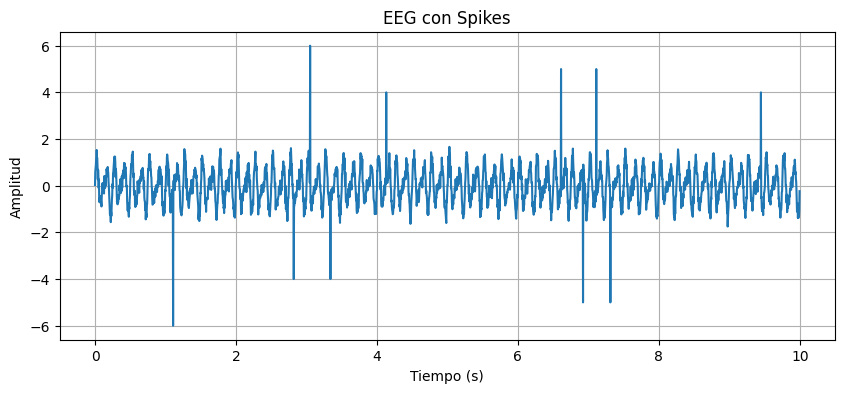

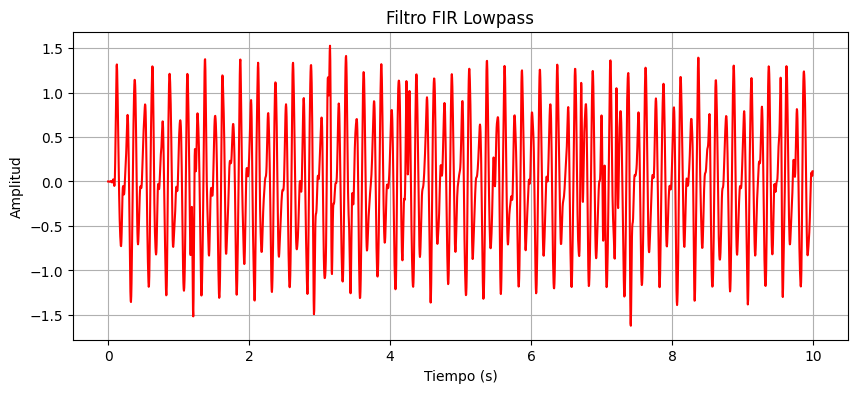

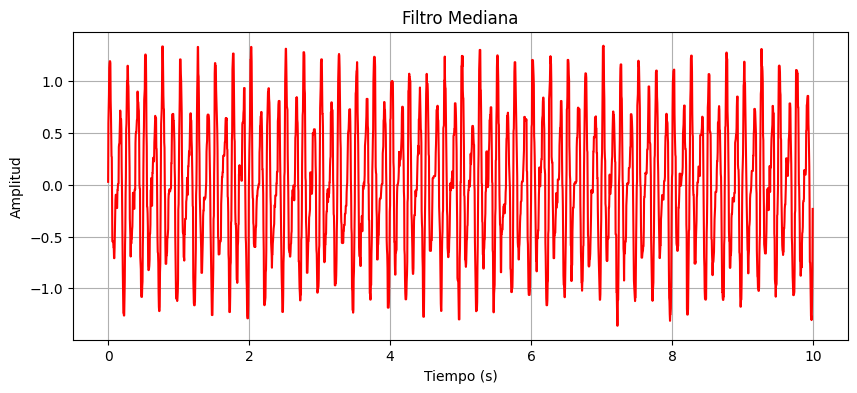

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

fs = 250
dur = 10

n = np.arange(fs*dur)
t = n/fs

# EEG simulado
eeg = (
    0.8*np.sin(2*np.pi*8*t) +
    0.5*np.sin(2*np.pi*12*t) +
    0.2*np.random.randn(len(t))
)

# Spikes aleatorios
np.random.seed(0)

pos = np.random.randint(0,len(eeg),10)

eeg_spikes = eeg.copy()

eeg_spikes[pos[0]] = 5
eeg_spikes[pos[1]] = -4
eeg_spikes[pos[2]] = 6
eeg_spikes[pos[3]] = -5
eeg_spikes[pos[4]] = 4
eeg_spikes[pos[5]] = -6
eeg_spikes[pos[6]] = 5
eeg_spikes[pos[7]] = -5
eeg_spikes[pos[8]] = 4
eeg_spikes[pos[9]] = -4

# FIR lowpass
fir = firwin(
    51,
    30,
    fs=fs
)

filtered_fir = lfilter(fir,1.0,eeg_spikes)

#Filtro mediana
filtered_med = medfilt(eeg_spikes,5)

# EEG con spikes
plt.figure(figsize=(10,4))
plt.plot(t,eeg_spikes)
plt.title("EEG con Spikes")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# FIR lowpass
plt.figure(figsize=(10,4))
plt.plot(t,filtered_fir,color='red')
plt.title("Filtro FIR Lowpass")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# Filtro mediana
plt.figure(figsize=(10,4))
plt.plot(t,filtered_med,color='red')
plt.title("Filtro Mediana")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Explicacion:  
En este caso sería el filtro mediana porque este reemplaza los valores extremos por la mediana de las muestras vecinas lo que elimina de manera más efectiva los picos repentinos sin alterar de froma significativa la forma de la señal. En cambio en el FIR pasa bajos los spikes impulsivos aún permanecen visibles debido a que este tipo de filtro está diseñado principalmente para atenuar componentes de alta frecuencia y no valores abruptos aislados.
Por lo que para señales en los que se tienen spikes seria mejor utilizar el filtro de mediana.

# **Ejercicio 4**

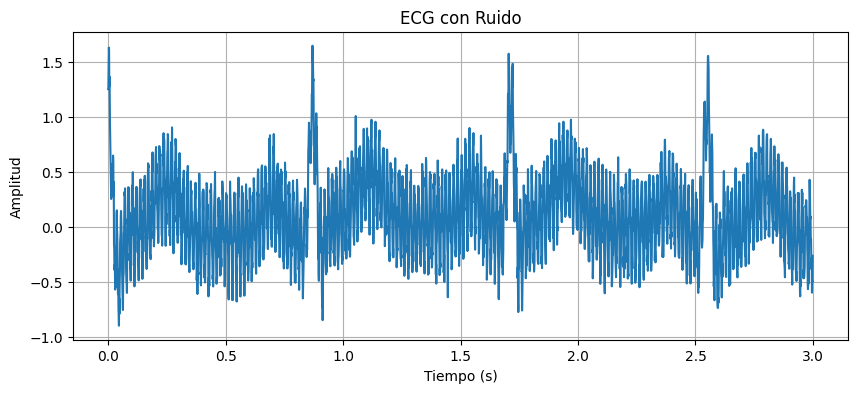

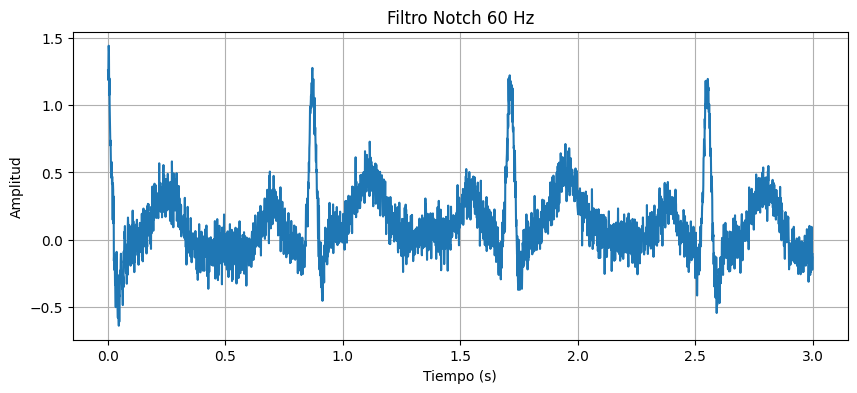

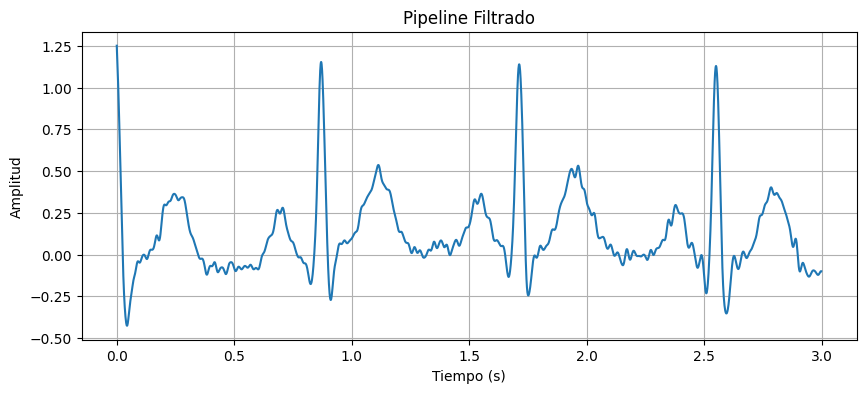

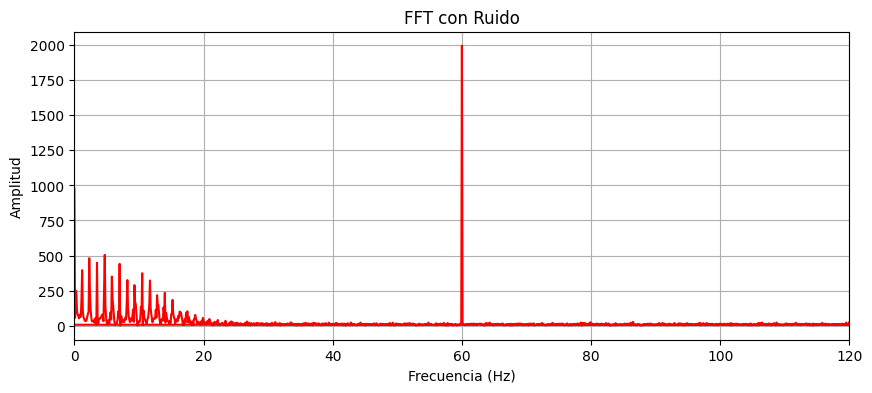

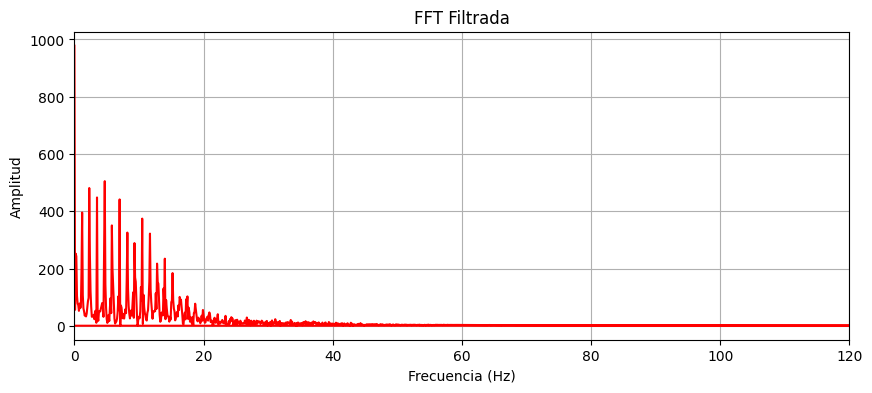

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import iirnotch, butter, filtfilt

fs = 1000
dur = 10

n = np.arange(fs*dur)
t = n/fs

# ECG
ecg = nk.ecg_simulate(
    duration=dur,
    sampling_rate=fs,
    heart_rate=70
)

# Ruido a 60Hz
noise_60 = 0.4*np.sin(2*np.pi*60*t)

# Ruido blanco
np.random.seed(0)
white_noise = np.random.normal(0,0.1,len(t))

# Señal con ruido
noisy = ecg + noise_60 + white_noise

# Notch 60 Hz
b_notch, a_notch = iirnotch(
    60,
    30,
    fs
)

filtered_notch = filtfilt(
    b_notch,
    a_notch,
    noisy
)

# Pasa bajos
b_lp, a_lp = butter(
    4,
    40,
    btype='low',
    fs=fs
)

filtered = filtfilt(
    b_lp,
    a_lp,
    filtered_notch
)

# ruido ecg
plt.figure(figsize=(10,4))
plt.plot(t[:3000],noisy[:3000])
plt.title("ECG con Ruido")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# ECG depues notch
plt.figure(figsize=(10,4))
plt.plot(t[:3000],filtered_notch[:3000])
plt.title("Filtro Notch 60 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# ECG filtrado final
plt.figure(figsize=(10,4))
plt.plot(t[:3000],filtered[:3000])
plt.title("Pipeline Filtrado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

#FFT señal ruido
fft_noisy = np.fft.fft(noisy)
freq = np.fft.fftfreq(len(noisy),1/fs)

plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_noisy),color='red')
plt.title("FFT con Ruido")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,120)
plt.grid()
plt.show()

#FFT señal filtrada
fft_filtered = np.fft.fft(filtered)

plt.figure(figsize=(10,4))
plt.plot(freq,np.abs(fft_filtered),color='red')
plt.title("FFT Filtrada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,120)
plt.grid()
plt.show()

# **Ejercicio 5**

Delay ECG: -2001
Delay Respiracion: -2000
Delay Acelerometro: -1


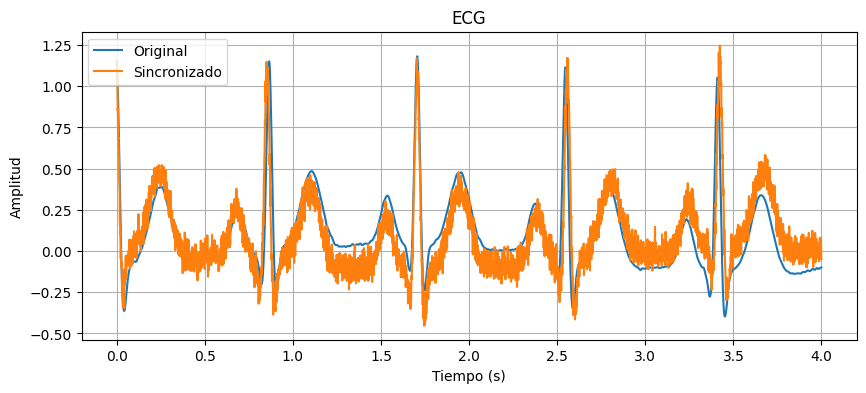

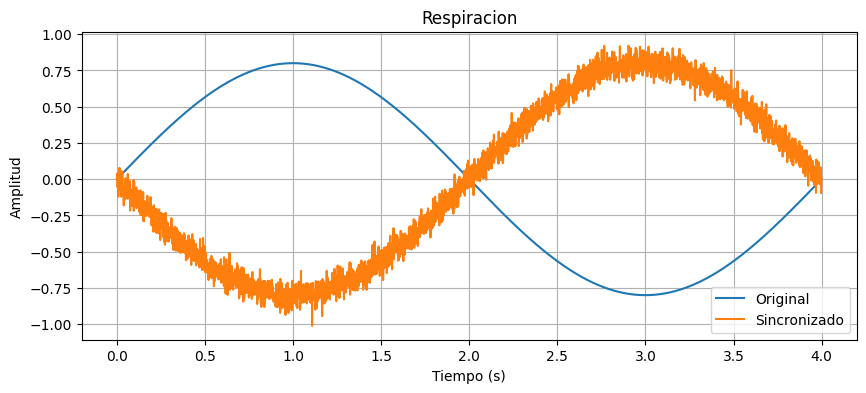

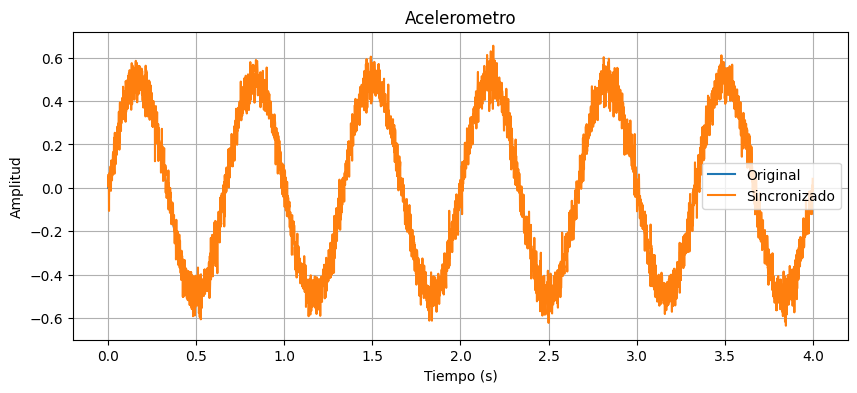

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import correlate

fs = 1000
dur = 10

n = np.arange(fs*dur)
t = n/fs

# ECG
ecg = nk.ecg_simulate(
    duration=dur,
    sampling_rate=fs,
    heart_rate=70
)

#Respiracion
resp = 0.8*np.sin(2*np.pi*0.25*t)

#Acelerometro
acc = 0.5*np.sin(2*np.pi*1.5*t)

# Delay de 2 segundos
delay = 2*fs

ecg_delay = np.roll(ecg,delay)
resp_delay = np.roll(resp,delay)
acc_delay = np.roll(acc,delay)


np.random.seed(0)# Ruido gausiano

ecg_delay = ecg_delay + np.random.normal(0,0.05,len(t))
resp_delay = resp_delay + np.random.normal(0,0.05,len(t))
acc_delay = acc_delay + np.random.normal(0,0.05,len(t))

# Correlacion en ECG
corr_ecg = correlate(ecg,ecg_delay)
delay_ecg = np.argmax(corr_ecg) - len(ecg)

#Correlacion respiracion
corr_resp = correlate(resp,resp_delay)
delay_resp = np.argmax(corr_resp) - len(resp)

# Correlacion acelerometro
corr_acc = correlate(acc,acc_delay)
delay_acc = np.argmax(corr_acc) - len(acc)

print("Delay ECG:",delay_ecg)
print("Delay Respiracion:",delay_resp)
print("Delay Acelerometro:",delay_acc)

#Sincronizacion
ecg_sync = np.roll(ecg_delay,-delay_ecg)
resp_sync = np.roll(resp_delay,-delay_resp)
acc_sync = np.roll(acc_delay,-delay_acc)

# ECG sincronizado
plt.figure(figsize=(10,4))
plt.plot(t[:4000],ecg[:4000],label='Original')
plt.plot(t[:4000],ecg_sync[:4000],label='Sincronizado')
plt.title("ECG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

# Resp sincronizada
plt.figure(figsize=(10,4))
plt.plot(t[:4000],resp[:4000],label='Original')
plt.plot(t[:4000],resp_sync[:4000],label='Sincronizado')
plt.title("Respiracion")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

# Acelerometro sincronizado
plt.figure(figsize=(10,4))
plt.plot(t[:4000],acc[:4000],label='Original')
plt.plot(t[:4000],acc_sync[:4000],label='Sincronizado')
plt.title("Acelerometro")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

# **Ejercicio 6**

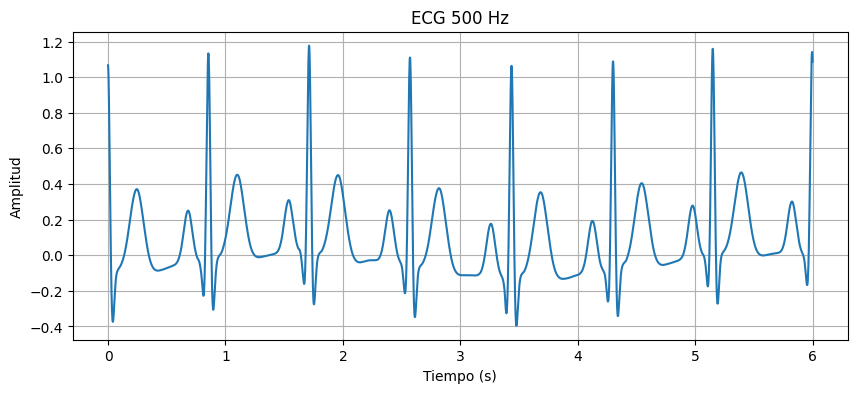

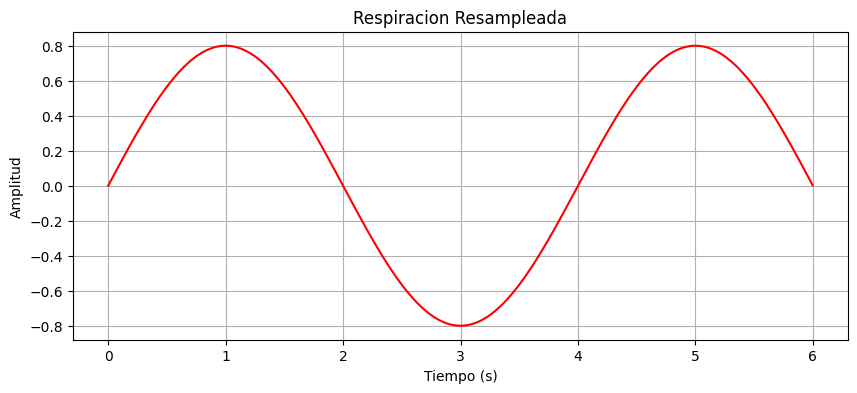

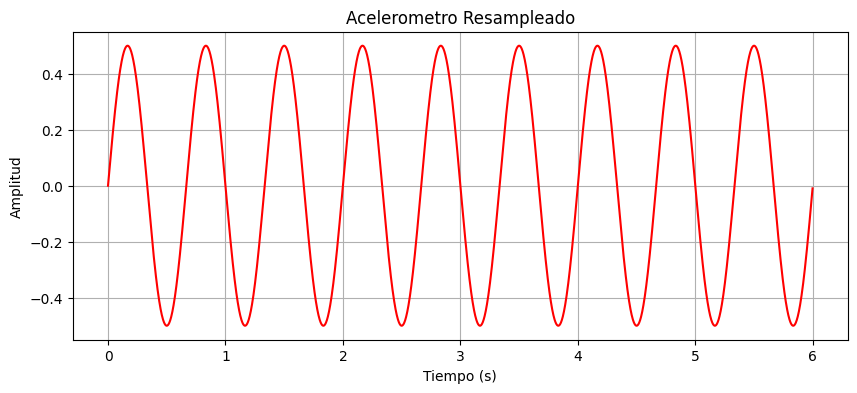

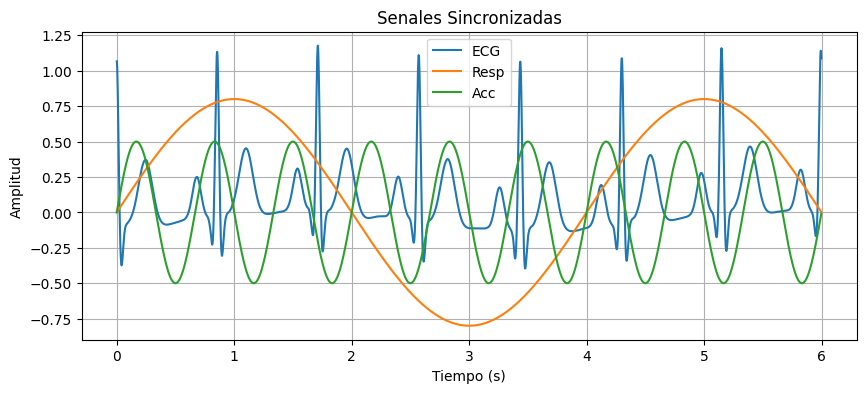

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import resample

dur = 10

fs_ecg = 500

n_ecg = np.arange(fs_ecg*dur)
t_ecg = n_ecg/fs_ecg

ecg = nk.ecg_simulate(
    duration=dur,
    sampling_rate=fs_ecg,
    heart_rate=70
)

# Respiracion en 100 Hz
fs_resp = 100

n_resp = np.arange(fs_resp*dur)
t_resp = n_resp/fs_resp

resp = 0.8*np.sin(2*np.pi*0.25*t_resp)

# Acelerometro 200Hz
fs_acc = 200

n_acc = np.arange(fs_acc*dur)
t_acc = n_acc/fs_acc

acc = 0.5*np.sin(2*np.pi*1.5*t_acc)

#Resamp a 500 Hz
resp_resampled = resample(
    resp,
    len(ecg)
)

acc_resampled = resample(
    acc,
    len(ecg)
)

plt.figure(figsize=(10,4))
plt.plot(t_ecg[:3000],ecg[:3000])
plt.title("ECG 500 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# Respiracion resampleada
plt.figure(figsize=(10,4))
plt.plot(t_ecg[:3000],resp_resampled[:3000],color='red')
plt.title("Respiracion Resampleada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# Acelrometro resampleado
plt.figure(figsize=(10,4))
plt.plot(t_ecg[:3000],acc_resampled[:3000],color='red')
plt.title("Acelerometro Resampleado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# Señales sincronizadas
plt.figure(figsize=(10,4))
plt.plot(t_ecg[:3000],ecg[:3000],label='ECG')
plt.plot(t_ecg[:3000],resp_resampled[:3000],label='Resp')
plt.plot(t_ecg[:3000],acc_resampled[:3000],label='Acc')
plt.title("Senales Sincronizadas")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()